# approxQPEQPUF – 1-Target Qubit, Two-Stage QPE

**Protocol (mid-circuit measurement, Qiskit)**

| | Stage 1 | Stage 2 |
|--|--|--|
| Precision qubits | `prec1` (n_prec) | `prec2` (n_prec) |
| Target qubit | shared (1 qubit) | same, after collapse |
| Measurement | mid-circuit → `c1` | final → `c2` |

The 1-qubit Haar-random unitary U is generated via ZYZ Euler decomposition.

**Sections**
- **A** Local simulation (AerSimulator) — set parameters and verify the protocol
- **B** Hardware results — load completed jobs from `job_results/` and analyse

In [43]:
import json
import os
import glob

import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.circuit.library import QFTGate
from qiskit_aer import AerSimulator

## Helper Functions

In [44]:
def haar_random_1qubit_matrix(rng=None):
    """
    Returns (U, angles) where U is a 2x2 Haar-random unitary matrix
    via ZYZ Euler decomposition: U = Rz(phi) @ Ry(theta) @ Rz(lam).

    Sampling:
      phi, lam ~ Uniform[0, 2pi)
      theta = 2 * arccos(sqrt(u)),  u ~ Uniform[0, 1]   (Haar-correct)
    """
    if rng is None:
        rng = np.random.default_rng()

    phi   = rng.uniform(0, 2 * np.pi)
    lam   = rng.uniform(0, 2 * np.pi)
    u     = rng.uniform(0, 1)
    theta = 2 * np.arccos(np.sqrt(u))

    def Rz(a):
        return np.array([[np.exp(-1j * a / 2), 0.0],
                         [0.0,                 np.exp(1j * a / 2)]])

    def Ry(a):
        return np.array([[ np.cos(a / 2), -np.sin(a / 2)],
                         [ np.sin(a / 2),  np.cos(a / 2)]])

    U = Rz(phi) @ Ry(theta) @ Rz(lam)
    return U, dict(phi=phi, theta=theta, lam=lam)


def build_qpe_circuit(n_prec: int, angles: dict) -> QuantumCircuit:
    """
    Build a 1-qubit QPE sub-circuit using direct controlled-RzRyRz gates.
    U^(2^k) is realised by repeating the gate sequence 2^k times.
    Qubit layout: [prec[0], ..., prec[n_prec-1], target]
    """
    n_targ = 1
    total  = n_prec + n_targ

    qc   = QuantumCircuit(total, name='QPE')
    prec = list(range(n_prec))
    targ = n_prec

    phi, theta, lam = angles['phi'], angles['theta'], angles['lam']

    qc.h(prec)

    for k in range(n_prec):
        ctrl = prec[k]
        for _ in range(2 ** k):
            qc.crz(lam,   ctrl, targ)
            qc.cry(theta, ctrl, targ)
            qc.crz(phi,   ctrl, targ)

    iqft = QFTGate(n_prec).inverse()
    qc.append(iqft, prec)

    return qc


def cyclic_distance(a: int, b: int, n_prec: int) -> int:
    """Cyclic distance |a - b| mod 2^n_prec."""
    M    = 2 ** n_prec
    diff = abs(a - b)
    return min(diff, M - diff)


def parse_outcome(bitstring: str, n_prec: int):
    """
    Parse a counts key that may be in one of two formats:
      - Qiskit named-register format: 'c2_bits c1_bits' (space-separated)
      - Braket/compact format: single concatenated string of length 2*n_prec
        where the left n_prec chars are c2 (m2) and the right n_prec chars are c1 (m1)
    Returns (m1, m2) as integers.
    """
    parts = bitstring.split(' ')
    if len(parts) == 2:
        return int(parts[1], 2), int(parts[0], 2)
    else:
        # Compact format: left half = c2 (m2), right half = c1 (m1)
        return int(bitstring[n_prec:], 2), int(bitstring[:n_prec], 2)


def analyse_counts(counts: dict, n_prec: int, delta: int, label: str = ''):
    """Print acceptance stats and top outcomes for a counts dict."""
    total    = sum(counts.values())
    accepted = sum(
        cnt for outcome, cnt in counts.items()
        if cyclic_distance(*parse_outcome(outcome, n_prec), n_prec) <= delta
    )
    acc_rate = accepted / total

    prefix = f'[{label}] ' if label else ''
    print(f'{prefix}Total shots        : {total}')
    print(f'{prefix}Accepted (dist <= {delta}) : {accepted}')
    print(f'{prefix}Acceptance rate    : {acc_rate:.4f}')

    print(f'\n{prefix}Top 10 outcomes:')
    print(f'  {"bitstring":28s}  m1  m2  dist  count')
    print(f'  {"-"*52}')
    for k, v in sorted(counts.items(), key=lambda x: -x[1])[:10]:
        m1, m2 = parse_outcome(k, n_prec)
        print(f'  {k!r:28s}  {m1:3d}  {m2:3d}  {cyclic_distance(m1, m2, n_prec):4d}  {v}')

    return total, accepted, acc_rate


def angles_to_unitary(angles: dict) -> np.ndarray:
    phi, theta, lam = angles['phi'], angles['theta'], angles['lam']
    def Rz(a): return np.array([[np.exp(-1j*a/2), 0], [0, np.exp(1j*a/2)]])
    def Ry(a): return np.array([[np.cos(a/2), -np.sin(a/2)], [np.sin(a/2), np.cos(a/2)]])
    return Rz(phi) @ Ry(theta) @ Rz(lam)


def print_eigenvalue_bins(angles: dict, n_prec: int):
    unitary = angles_to_unitary(angles)
    print('Theoretical QPE bins (ideal):')
    for ev in np.linalg.eigvals(unitary):
        phase = np.angle(ev) / (2 * np.pi)
        if phase < 0:
            phase += 1
        print(f'  phase={phase:.4f}  ideal bin={round(phase * 2**n_prec) % 2**n_prec}')


def plot_m1_vs_m2(counts: dict, n_prec: int, n_shots: int, title_suffix: str = ''):
    """Scatter plot of m1 vs m2 phase estimates."""
    m1_vals, m2_vals, weights = [], [], []
    for outcome, count in counts.items():
        m1, m2 = parse_outcome(outcome, n_prec)
        m1_vals.append(m1)
        m2_vals.append(m2)
        weights.append(count)

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(m1_vals, m2_vals, s=np.array(weights) * 2.0, alpha=0.6)
    ax.plot([0, 2**n_prec - 1], [0, 2**n_prec - 1], 'r--', label='m1 = m2')
    ax.set_xlabel('m1  (Stage 1 QPE)')
    ax.set_ylabel('m2  (Stage 2 QPE)')
    title = f'Phase estimates – 1-qubit Haar unitary\n(n_prec={n_prec}, n_shots={n_shots})'
    if title_suffix:
        title += f'  {title_suffix}'
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()


def plot_acceptance_vs_delta(counts: dict, n_prec: int, n_shots: int, delta: int):
    """Plot acceptance rate as a function of the delta threshold."""
    total       = sum(counts.values())
    delta_range = list(range(0, 2**n_prec + 1))
    acc_rates   = []

    for d in delta_range:
        acc = sum(
            cnt for outcome, cnt in counts.items()
            if cyclic_distance(*parse_outcome(outcome, n_prec), n_prec) <= d
        )
        acc_rates.append(acc / total)

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(delta_range, acc_rates, marker='o', markersize=4)
    ax.axvline(delta, color='r', linestyle='--', label=f'current delta={delta}')
    ax.set_xlabel('delta  (cyclic distance threshold)')
    ax.set_ylabel('acceptance rate')
    ax.set_title(f'Acceptance rate vs delta  (n_prec={n_prec}, n_shots={n_shots})')
    ax.legend()
    plt.tight_layout()
    plt.show()

    print('\ndelta -> acceptance rate')
    for d, r in zip(delta_range, acc_rates):
        print(f'  delta={d:3d}: {r:.4f}')

In [45]:
def run_local_sim(n_prec, n_targ, seed, n_shots, delta=2):
    """
    Build and run the two-stage QPE circuit on AerSimulator.

    Constructs a Haar-random unitary from `seed`, builds the full two-stage QPE
    circuit with `n_prec` precision qubits and `n_targ` target qubit(s), runs
    `n_shots` on AerSimulator, and returns a result dict compatible with
    plot_hw_vs_sim().

    Returns
    -------
    dict with keys: counts, angles, n_prec, n_targ, n_shots, delta, seed
    """
    rng = np.random.default_rng(seed=seed)
    _, angles = haar_random_1qubit_matrix(rng=rng)

    targ_reg  = QuantumRegister(n_targ, 'target')
    prec1_reg = QuantumRegister(n_prec, 'prec1')
    prec2_reg = QuantumRegister(n_prec, 'prec2')
    c1        = ClassicalRegister(n_prec, 'c1')
    c2        = ClassicalRegister(n_prec, 'c2')

    qc = QuantumCircuit(targ_reg, prec1_reg, prec2_reg, c1, c2)

    # Random initial target state (fixed seed matches hardware submit_job.py)
    init_rng = np.random.default_rng(seed=99)
    theta0, phi0 = init_rng.uniform(0, np.pi), init_rng.uniform(0, 2 * np.pi)
    qc.ry(theta0, targ_reg[0])
    qc.rz(phi0,   targ_reg[0])

    # Stage 1 QPE + mid-circuit measurement
    qpe1 = build_qpe_circuit(n_prec, angles)
    qc.append(qpe1, list(prec1_reg) + list(targ_reg))
    qc.measure(prec1_reg, c1)

    # Stage 2 QPE + final measurement
    qpe2 = build_qpe_circuit(n_prec, angles)
    qc.append(qpe2, list(prec2_reg) + list(targ_reg))
    qc.measure(prec2_reg, c2)

    simulator  = AerSimulator()
    transpiled = transpile(qc, simulator)
    counts     = simulator.run(transpiled, shots=n_shots).result().get_counts()

    return {
        'counts':  counts,
        'angles':  angles,
        'n_prec':  n_prec,
        'n_targ':  n_targ,
        'n_shots': n_shots,
        'delta':   delta,
        'seed':    seed,
    }


def plot_hw_vs_sim(hw, sim, save=True):
    """
    2×2 comparison figure: hardware (left column) vs local simulator (right column).

      Row 0 : m1 vs m2 scatter plot
      Row 1 : acceptance rate vs delta curve

    Parameters
    ----------
    hw, sim : dicts with keys: counts, n_prec, n_shots, delta
              Optional key 'label' used in subplot titles.
              hw may also carry 'job_id' (full ARN or bare UUID) used for the filename.
    save    : bool, default True.
              If True, saves the figure as <plots_dir>/<uuid>.png where plots_dir is
              'plots/' relative to the current working directory.
    """
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    hw_label  = hw.get('label',  'Hardware')
    sim_label = sim.get('label', 'Local Simulator')

    def _scatter(ax, result, label):
        counts  = result['counts']
        n_prec  = result['n_prec']
        n_shots = result['n_shots']
        m1_vals, m2_vals, weights = [], [], []
        for outcome, count in counts.items():
            m1, m2 = parse_outcome(outcome, n_prec)
            m1_vals.append(m1)
            m2_vals.append(m2)
            weights.append(count)
        ax.scatter(m1_vals, m2_vals, s=np.array(weights) * 2.0, alpha=0.6)
        ax.plot([0, 2**n_prec - 1], [0, 2**n_prec - 1], 'r--', label='m1 = m2')
        ax.set_xlabel('m1  (Stage 1 QPE)')
        ax.set_ylabel('m2  (Stage 2 QPE)')
        ax.set_title(f'm1 vs m2  –  {label}\n(n_prec={n_prec}, n_shots={n_shots})')
        ax.legend()

    def _delta_curve(ax, result, label):
        counts      = result['counts']
        n_prec      = result['n_prec']
        n_shots     = result['n_shots']
        delta       = result.get('delta', 2)
        total       = sum(counts.values())
        delta_range = list(range(0, 2**n_prec + 1))
        acc_rates   = [
            sum(cnt for outcome, cnt in counts.items()
                if cyclic_distance(*parse_outcome(outcome, n_prec), n_prec) <= d) / total
            for d in delta_range
        ]
        ax.plot(delta_range, acc_rates, marker='o', markersize=4)
        ax.axvline(delta, color='r', linestyle='--', label=f'delta={delta}')
        ax.set_xlabel('delta  (cyclic distance threshold)')
        ax.set_ylabel('acceptance rate')
        ax.set_title(f'Acceptance vs delta  –  {label}\n(n_prec={n_prec}, n_shots={n_shots})')
        ax.legend()

    _scatter    (axes[0, 0], hw,  hw_label)
    _scatter    (axes[0, 1], sim, sim_label)
    _delta_curve(axes[1, 0], hw,  hw_label)
    _delta_curve(axes[1, 1], sim, sim_label)

    fig.suptitle('Hardware vs Local Simulator – Two-Stage QPE QPUF', fontsize=13)
    plt.tight_layout()

    if save:
        job_id   = hw.get('job_id', '')
        uuid_str = job_id.split('/')[-1] if job_id else 'unknown'
        plots_dir = os.path.join(os.getcwd(), 'plots')
        os.makedirs(plots_dir, exist_ok=True)
        out_path = os.path.join(plots_dir, f'{uuid_str}.png')
        fig.savefig(out_path, dpi=150, bbox_inches='tight')
        print(f'Saved → {out_path}')

    plt.show()

---
## Section A – Local Simulation

Run the two-stage QPE circuit on `AerSimulator` — supports mid-circuit measurements natively.  
Set the parameters below, then run all cells in this section.

### A-1: Parameters

In [46]:
n_prec  = 7      # precision qubits per QPE stage
n_target = 1     # target qubits (currently only 1-qubit unitaries are supported)
n_shots = 1000   # shots for local simulation
delta   = 2      # cyclic-distance acceptance threshold
seed    = 42     # RNG seed for Haar-random unitary

rng = np.random.default_rng(seed=seed)
unitary, angles = haar_random_1qubit_matrix(rng=rng)

print(f'n_prec={n_prec}, n_target={n_target}, n_shots={n_shots}, delta={delta}, seed={seed}')
print(f'\nEuler angles:  phi={angles["phi"]:.4f}  theta={angles["theta"]:.4f}  lam={angles["lam"]:.4f}')
print_eigenvalue_bins(angles, n_prec)

n_prec=7, n_target=1, n_shots=1000, delta=2, seed=42

Euler angles:  phi=4.8629  theta=0.7710  lam=2.7576
Theoretical QPE bins (ideal):
  phase=0.3796  ideal bin=49
  phase=0.6204  ideal bin=79


### A-2: Build Circuit

In [47]:
targ_reg  = QuantumRegister(n_target, 'target')
prec1_reg = QuantumRegister(n_prec,   'prec1')
prec2_reg = QuantumRegister(n_prec,   'prec2')
c1        = ClassicalRegister(n_prec, 'c1')
c2        = ClassicalRegister(n_prec, 'c2')

qc = QuantumCircuit(targ_reg, prec1_reg, prec2_reg, c1, c2)

# Target: random single-qubit initial state
init_rng = np.random.default_rng(seed=99)
theta0, phi0 = init_rng.uniform(0, np.pi), init_rng.uniform(0, 2 * np.pi)
qc.ry(theta0, targ_reg[0])
qc.rz(phi0,   targ_reg[0])

# Stage 1 QPE
qpe1 = build_qpe_circuit(n_prec, angles)
qc.append(qpe1, list(prec1_reg) + list(targ_reg))

# Mid-circuit measurement
qc.measure(prec1_reg, c1)
qc.barrier(label='collapse')

# Stage 2 QPE
qpe2 = build_qpe_circuit(n_prec, angles)
qc.append(qpe2, list(prec2_reg) + list(targ_reg))

# Final measurement
qc.measure(prec2_reg, c2)

print(f'Total qubits   : {qc.num_qubits}  (2x{n_prec} prec + {n_target} target)')
print(f'Classical bits : {qc.num_clbits}')
print(f'IonQ Forte budget check: {"OK (<=36)" if qc.num_qubits <= 36 else "TOO MANY QUBITS"}')

#qc.decompose(reps=1).draw(output='mpl', fold=80)

Total qubits   : 15  (2x7 prec + 1 target)
Classical bits : 14
IonQ Forte budget check: OK (<=36)


### A-3: Run Simulation

In [48]:
simulator  = AerSimulator()
transpiled = transpile(qc, simulator)
job_sim    = simulator.run(transpiled, shots=n_shots)
result     = job_sim.result()
counts     = result.get_counts()

print(f'Unique outcomes : {len(counts)}')

Unique outcomes : 133


In [49]:
total, accepted, acc_rate = analyse_counts(counts, n_prec, delta, label='Simulator')
print()
print_eigenvalue_bins(angles, n_prec)

[Simulator] Total shots        : 1000
[Simulator] Accepted (dist <= 2) : 857
[Simulator] Acceptance rate    : 0.8570

[Simulator] Top 10 outcomes:
  bitstring                     m1  m2  dist  count
  ----------------------------------------------------
  '1001111 1001111'              79   79     0  202
  '1010000 1001111'              79   80     1  110
  '1001111 1010000'              80   79     1  104
  '0110001 0110001'              49   49     0  81
  '0110000 0110001'              49   48     1  63
  '0110001 0110000'              48   49     1  60
  '1010000 1010000'              80   80     0  47
  '0110000 0110000'              48   48     0  20
  '1010001 1001111'              79   81     2  17
  '1001110 1001111'              79   78     1  15

Theoretical QPE bins (ideal):
  phase=0.3796  ideal bin=49
  phase=0.6204  ideal bin=79


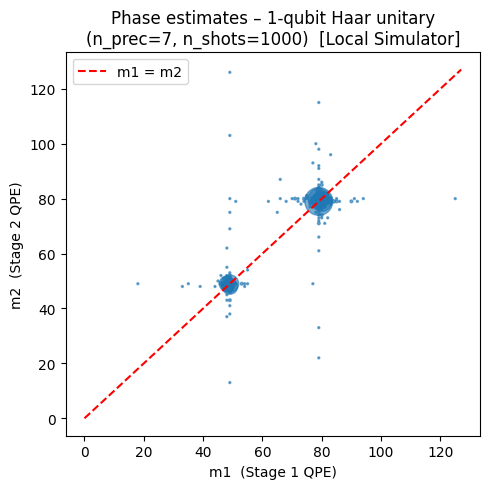

In [50]:
plot_m1_vs_m2(counts, n_prec, n_shots, title_suffix='[Local Simulator]')

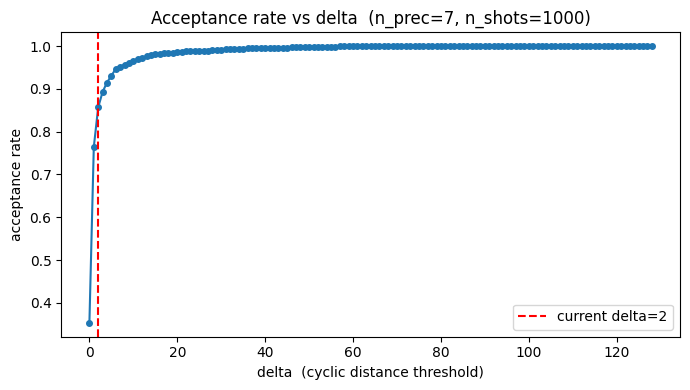


delta -> acceptance rate
  delta=  0: 0.3530
  delta=  1: 0.7640
  delta=  2: 0.8570
  delta=  3: 0.8930
  delta=  4: 0.9150
  delta=  5: 0.9310
  delta=  6: 0.9470
  delta=  7: 0.9520
  delta=  8: 0.9570
  delta=  9: 0.9610
  delta= 10: 0.9650
  delta= 11: 0.9710
  delta= 12: 0.9720
  delta= 13: 0.9760
  delta= 14: 0.9800
  delta= 15: 0.9810
  delta= 16: 0.9820
  delta= 17: 0.9830
  delta= 18: 0.9840
  delta= 19: 0.9850
  delta= 20: 0.9860
  delta= 21: 0.9870
  delta= 22: 0.9880
  delta= 23: 0.9880
  delta= 24: 0.9880
  delta= 25: 0.9880
  delta= 26: 0.9890
  delta= 27: 0.9890
  delta= 28: 0.9910
  delta= 29: 0.9910
  delta= 30: 0.9910
  delta= 31: 0.9930
  delta= 32: 0.9930
  delta= 33: 0.9930
  delta= 34: 0.9930
  delta= 35: 0.9930
  delta= 36: 0.9950
  delta= 37: 0.9950
  delta= 38: 0.9950
  delta= 39: 0.9950
  delta= 40: 0.9950
  delta= 41: 0.9950
  delta= 42: 0.9950
  delta= 43: 0.9950
  delta= 44: 0.9950
  delta= 45: 0.9960
  delta= 46: 0.9970
  delta= 47: 0.9970
  delta= 48: 0

In [51]:
plot_acceptance_vs_delta(counts, n_prec, n_shots, delta)

---
## Section B – Hardware Results

**Workflow**
1. Submit a job with `submit_job.py` — appends a record to `job_results/jobs_log.txt`
2. Run `checkRetrieve_job.py` on the DCV to fetch completed results into `job_results/<uuid>.json`
3. Run B-1 to see available jobs, then set `JOB_ID` in B-2 and run the analysis

### B-1: Available Jobs

In [52]:
JOB_RESULTS_DIR = os.path.join(os.getcwd(), 'job_results')
LOG_FILE        = os.path.join(JOB_RESULTS_DIR, 'jobs_log.txt')

if not os.path.exists(LOG_FILE):
    raise FileNotFoundError(
        f'Job log not found: {LOG_FILE}\n'
        'Run submit_job.py first to submit a job.'
    )

with open(LOG_FILE) as f:
    job_records = [json.loads(line) for line in f if line.strip()]

# Check which jobs have a result file ready
print(f'Found {len(job_records)} job record(s) in jobs_log.txt\n')
print(f'  {"#":>3}  {"datetime":32s}  {"qpu":8s}  {"n_prec":6s}  {"n_shots":7s}  {"result":8s}  uuid')
print(f'  {"-"*95}')
for i, rec in enumerate(job_records):
    uuid      = rec['job_id'].split('/')[-1]
    has_result = os.path.exists(os.path.join(JOB_RESULTS_DIR, f'{uuid}.json'))
    status_str = 'ready' if has_result else 'pending'
    print(f'  {i:>3}  {rec["datetime"]:32s}  {rec["qpu"]:8s}  '
          f'{rec["n_prec"]:6d}  {rec["n_shots"]:7d}  {status_str:8s}  {uuid}')

Found 2 job record(s) in jobs_log.txt

    #  datetime                          qpu       n_prec  n_shots  result    uuid
  -----------------------------------------------------------------------------------------------
    0  2026-04-01T14:45:02.754978+00:00  Forte-1        7      400  ready     1c5965c8-e716-4f7a-a7f7-1f6f324ab108
    1  2026-04-01T14:50:40.049723+00:00  Forte-1        7      400  ready     d654d6f3-4489-46d2-afb0-0073c4ef53e6


### B-2: Select and Analyse a Job

Set `JOB_ID` to the full Braket ARN (or just the UUID part) of the job you want to analyse.  
The result file must already exist in `job_results/` (i.e. status = **ready** above).

In [58]:
# ── Set this to the job ID (ARN) or UUID you want to analyse ──────────────
JOB_ID = "arn:aws:braket:us-east-1::quantum-task/d654d6f3-4489-46d2-afb0-0073c4ef53e6"
# ──────────────────────────────────────────────────────────────────────────

# Accept either full ARN or bare UUID
uuid = JOB_ID.split('/')[-1]
result_path = os.path.join(JOB_RESULTS_DIR, f'{uuid}.json')

if not os.path.exists(result_path):
    raise FileNotFoundError(
        f'Result file not found: {result_path}\n'
        'Run checkRetrieve_job.py on the DCV first.'
    )

with open(result_path) as f:
    hw = json.load(f)

hw_n_prec  = hw['n_prec']
hw_n_shots = hw['n_shots']
hw_angles  = hw['angles']
hw_counts  = hw['counts']
hw_qpu     = hw['qpu']

print(f'Job ID    : {hw["job_id"]}')
print(f'Submitted : {hw["datetime"]}')
print(f'QPU       : {hw_qpu}')
print(f'n_prec    : {hw_n_prec}')
print(f'n_shots   : {hw_n_shots}')
print(f'seed      : {hw.get("seed")}')
print(f'Angles    : phi={hw_angles["phi"]:.6f}  '
      f'theta={hw_angles["theta"]:.6f}  lam={hw_angles["lam"]:.6f}')

Job ID    : arn:aws:braket:us-east-1:767397707562:quantum-task/d654d6f3-4489-46d2-afb0-0073c4ef53e6
Submitted : 2026-04-01T14:50:40.049723+00:00
QPU       : Forte-1
n_prec    : 7
n_shots   : 400
seed      : 33
Angles    : phi=2.787486  theta=0.615980  lam=3.571936


In [59]:
hw_delta = delta   # reuse delta from Section A, or override here

total_hw, accepted_hw, acc_rate_hw = analyse_counts(
    hw_counts, hw_n_prec, hw_delta, label=f'{hw_qpu} hardware'
)
print()
print_eigenvalue_bins(hw_angles, hw_n_prec)

[Forte-1 hardware] Total shots        : 400
[Forte-1 hardware] Accepted (dist <= 2) : 282
[Forte-1 hardware] Acceptance rate    : 0.7050

[Forte-1 hardware] Top 10 outcomes:
  bitstring                     m1  m2  dist  count
  ----------------------------------------------------
  '01110100111010'               58   58     0  149
  '01110100111001'               57   58     1  26
  '01110010111010'               58   57     1  24
  '10001101000110'               70   70     0  20
  '01110100111011'               59   58     1  10
  '01110110111010'               58   59     1  10
  '01110100111110'               62   58     4  8
  '10001111000110'               70   71     1  7
  '01110100111000'               56   58     2  6
  '01110010111001'               57   57     0  5

Theoretical QPE bins (ideal):
  phase=0.4506  ideal bin=58
  phase=0.5494  ideal bin=70


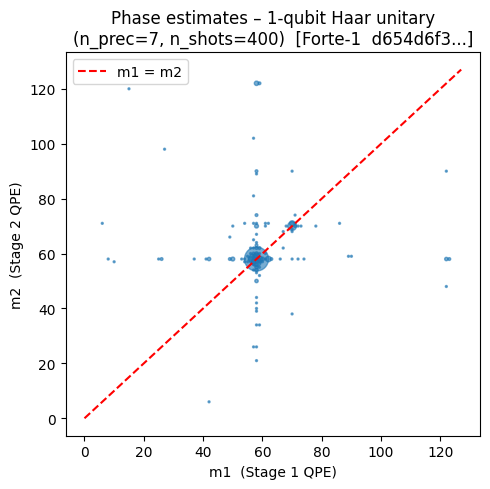

In [60]:
plot_m1_vs_m2(hw_counts, hw_n_prec, hw_n_shots,
              title_suffix=f'[{hw_qpu}  {uuid[:8]}...]')

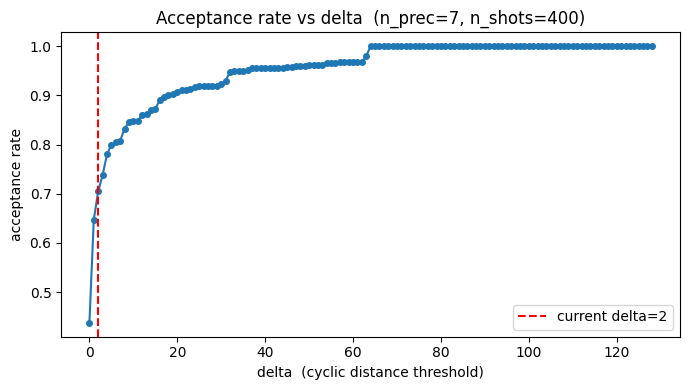


delta -> acceptance rate
  delta=  0: 0.4375
  delta=  1: 0.6475
  delta=  2: 0.7050
  delta=  3: 0.7375
  delta=  4: 0.7800
  delta=  5: 0.8000
  delta=  6: 0.8050
  delta=  7: 0.8075
  delta=  8: 0.8325
  delta=  9: 0.8450
  delta= 10: 0.8475
  delta= 11: 0.8475
  delta= 12: 0.8600
  delta= 13: 0.8625
  delta= 14: 0.8700
  delta= 15: 0.8725
  delta= 16: 0.8900
  delta= 17: 0.8975
  delta= 18: 0.9000
  delta= 19: 0.9025
  delta= 20: 0.9075
  delta= 21: 0.9100
  delta= 22: 0.9100
  delta= 23: 0.9125
  delta= 24: 0.9175
  delta= 25: 0.9200
  delta= 26: 0.9200
  delta= 27: 0.9200
  delta= 28: 0.9200
  delta= 29: 0.9200
  delta= 30: 0.9225
  delta= 31: 0.9300
  delta= 32: 0.9475
  delta= 33: 0.9500
  delta= 34: 0.9500
  delta= 35: 0.9500
  delta= 36: 0.9525
  delta= 37: 0.9550
  delta= 38: 0.9550
  delta= 39: 0.9550
  delta= 40: 0.9550
  delta= 41: 0.9550
  delta= 42: 0.9550
  delta= 43: 0.9550
  delta= 44: 0.9550
  delta= 45: 0.9575
  delta= 46: 0.9575
  delta= 47: 0.9600
  delta= 48: 0

In [61]:
plot_acceptance_vs_delta(hw_counts, hw_n_prec, hw_n_shots, hw_delta)

---
## Section C – Hardware vs Simulator Comparison

Runs `run_local_sim` with the same parameters as the selected hardware job (from Section B),
then displays all four plots side-by-side in a single 2×2 figure.

| | Left column | Right column |
|--|--|--|
| **Row 0** | Hardware m1 vs m2 | Simulator m1 vs m2 |
| **Row 1** | Hardware acceptance vs delta | Simulator acceptance vs delta |

Requires Section B cells to have been run first (`hw_counts`, `hw_n_prec`, etc. must be defined).

Saved → /Users/user/python/QUEN_QPUF/garnet-approxQPEQPUF-1target/plots/d654d6f3-4489-46d2-afb0-0073c4ef53e6.png


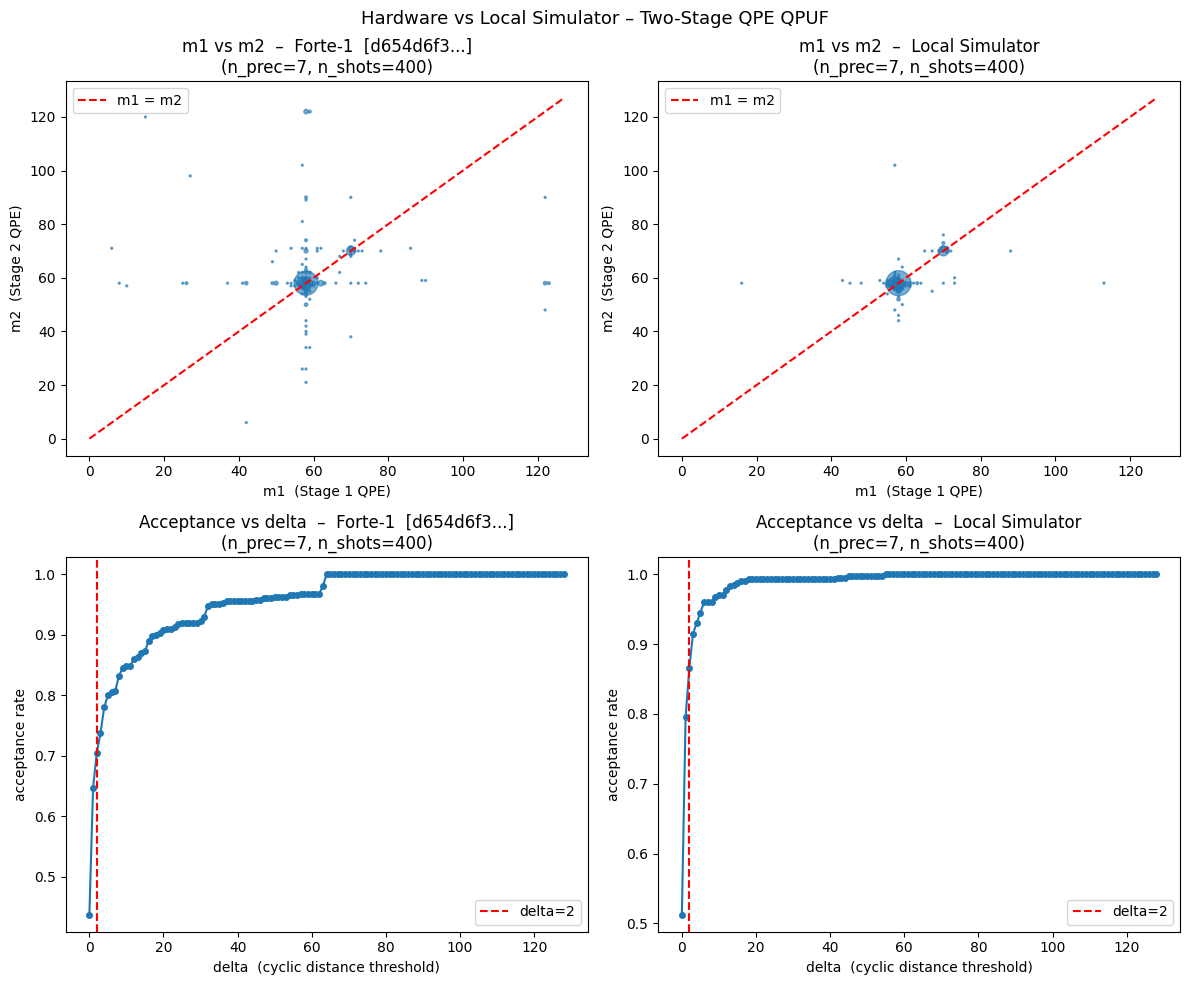

In [62]:
# Run simulator with the same parameters as the loaded hardware job
sim_result = run_local_sim(
    n_prec  = hw_n_prec,
    n_targ  = 1,
    seed    = hw['seed'],
    n_shots = hw_n_shots,
    delta   = hw_delta,
)

hw_result = {
    'counts':  hw_counts,
    'angles':  hw_angles,
    'n_prec':  hw_n_prec,
    'n_shots': hw_n_shots,
    'delta':   hw_delta,
    'job_id':  hw['job_id'],
    'label':   f'{hw_qpu}  [{uuid[:8]}...]',
}
sim_result['label'] = 'Local Simulator'

plot_hw_vs_sim(hw_result, sim_result)